In [1]:
import sys, time, json, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# Verify PaddlePaddle + PaddleOCR are installed
try:
    import paddle
    print(f"PaddlePaddle: {paddle.__version__}")
    print(f"GPU available: {paddle.device.is_compiled_with_cuda()}")
    if paddle.device.is_compiled_with_cuda():
        print(f"GPU count:     {paddle.device.cuda.device_count()}")
        print(f"Current device: {paddle.device.get_device()}")
except ImportError:
    print("⚠ paddle not installed — run the install commands above first")
    raise

try:
    import paddleocr
    print(f"\nPaddleOCR:    {paddleocr.__version__}")
except ImportError:
    print("⚠ paddleocr not installed — run `pip install paddleocr`")
    raise

which: no ccache in (/home/luca/.venv-paddle/bin:/home/luca/gcc-arm-none-eabi-9-2020-q2-update/bin:/usr/local/sbin:/usr/local/bin:/usr/bin:/usr/lib/jvm/default/bin:/usr/bin/site_perl:/usr/bin/vendor_perl:/usr/bin/core_perl:/home/luca/.local/bin)
/home/luca/.venv-paddle/lib/python3.13/site-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


PaddlePaddle: 3.0.0
GPU available: True
GPU count:     1
Current device: gpu:0

PaddleOCR:    3.6.0


## 2. Load the cached frozen test set

In [2]:
# Same cache the CRNN/CNN notebooks built — guarantees comparable test images
WORK_ROOT  = Path("crnn_plate")
LABELS_CSV = WORK_ROOT / "labels.csv"
OUT_DIR    = Path("paddleocr_baseline"); OUT_DIR.mkdir(exist_ok=True)

assert LABELS_CSV.exists(), (
    f"Cache not found at {LABELS_CSV}. Run the CRNN notebook through section 4 first "
    f"to build the rectified-crop cache."
)

df = pd.read_csv(LABELS_CSV)
test_df = df[df["split"] == "test"].reset_index(drop=True)
print(f"Total cached crops: {len(df):,}")
print(f"Frozen test set:    {len(test_df):,}")
print("\nTest by subset:")
print(test_df["subset"].value_counts().sort_index().to_string())

Total cached crops: 7,750
Frozen test set:    1,163

Test by subset:
subset
ccpd_base         556
ccpd_blur          84
ccpd_challenge    161
ccpd_db            56
ccpd_fn            85
ccpd_rotate        56
ccpd_tilt         109
ccpd_weather       56


In [ ]:
from paddleocr import TextRecognition

MODEL_NAME = "PP-OCRv5_server_rec"

t0 = time.time()
recognizer = TextRecognition(model_name=MODEL_NAME)
print(f"Loaded {MODEL_NAME} in {time.time()-t0:.1f}s")

# Quick smoke test on one image
sample = test_df.iloc[0]
img = cv2.imread(sample["path"])
print(f"\nSmoke test:  truth = {sample['plate']!r}")

t0 = time.time()
out = recognizer.predict(input=sample["path"], batch_size=1)
dt = time.time() - t0
# Inspect the result object
for res in out:
    print(f"  paddleocr raw output: {res}")
    break
print(f"  inference time: {dt*1000:.1f} ms")

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in `/home/luca/.paddlex/official_models/PP-OCRv5_server_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loaded PP-OCRv5_server_rec in 10.6s

Smoke test:  truth = '皖MV1P80'
  paddleocr raw output: {'input_path': 'crnn_plate/crops/1020-25_35-299&428_593&718-564&591_299&718_328&555_593&428-0_11_19_25_13_32_24-151-48.jpg', 'page_index': None, 'input_img': array([[[255, ...,  95],
        ...,
        [109, ..., 110]],

       ...,

       [[192, ..., 152],
        ...,
        [159, ..., 123]]], shape=(48, 168, 3), dtype=uint8), 'rec_text': '皖M·VIP80', 'rec_score': 0.953413188457489, 'vis_font': <paddlex.utils.fonts.Font object at 0x7f751c11f890>}
  inference time: 355.2 ms


In [4]:
def extract_text_and_score(res):
    '''Pull (text, score) from a PaddleOCR result object across version variants.
    Returns ('', 0.0) on anything unparseable.'''
    if res is None: return "", 0.0
    # Newer (v3.x): result is dict-like with 'rec_text' and 'rec_score'
    for txt_key, sc_key in [("rec_text", "rec_score"), ("text", "score")]:
        if hasattr(res, "json"):
            try:
                d = res.json
                if isinstance(d, dict) and txt_key in d:
                    return str(d[txt_key]), float(d.get(sc_key, 0.0))
            except Exception: pass
        if hasattr(res, "get") and res.get(txt_key) is not None:
            return str(res[txt_key]), float(res.get(sc_key, 0.0))
        if hasattr(res, txt_key):
            return str(getattr(res, txt_key)), float(getattr(res, sc_key, 0.0))
    # Older: result is a tuple (text, score)
    if isinstance(res, (tuple, list)) and len(res) >= 2:
        try: return str(res[0]), float(res[1])
        except Exception: pass
    return "", 0.0

# Verify it works
out = recognizer.predict(input=sample["path"], batch_size=1)
for res in out:
    txt, sc = extract_text_and_score(res)
    print(f"  extracted text:  {txt!r}")
    print(f"  confidence:      {sc:.3f}")
    print(f"  truth:           {sample['plate']!r}")
    break

  extracted text:  '皖M·VIP80'
  confidence:      0.953
  truth:           '皖MV1P80'


In [ ]:
PROVINCES = ['皖','沪','津','渝','冀','晋','蒙','辽','吉','黑','苏','浙','京',
             '闽','赣','鲁','豫','鄂','湘','粤','桂','琼','川','贵','云','藏',
             '陕','甘','青','宁','新','警','学']                                # 33 (no 'O' sentinel)
LATIN_LETTERS = list("ABCDEFGHJKLMNPQRSTUVWXYZ")                                # 24 (no I, no O)
DIGITS        = list("0123456789")                                              # 10

VALID_POS1 = set(PROVINCES)
VALID_POS2 = set(LATIN_LETTERS)
VALID_POS37 = set(LATIN_LETTERS) | set(DIGITS)

def clean_prediction(raw: str) -> str:
    '''Normalize and trim PaddleOCR's raw output to a 7-char plate string.
    Returns the cleaned string (which may be shorter than 7 if the model missed chars).'''
    if raw is None: return ""
    s = str(raw).strip().upper()
    # Drop spaces and punctuation
    s = "".join(c for c in s if not c.isspace() and c not in ".,-•·")
    # Drop characters that can't appear anywhere on a plate
    all_valid = VALID_POS1 | VALID_POS2 | set(DIGITS)
    s = "".join(c for c in s if c in all_valid)
    return s[:7]

# Smoke test on a known plate
out = recognizer.predict(input=sample["path"], batch_size=1)
for res in out:
    raw, sc = extract_text_and_score(res)
    clean = clean_prediction(raw)
    print(f"raw:    {raw!r}")
    print(f"clean:  {clean!r}")
    print(f"truth:  {sample['plate']!r}")
    print(f"match:  {clean == sample['plate']}")
    break

raw:    '皖M·VIP80'
clean:  '皖MVP80'
truth:  '皖MV1P80'
match:  False


## 6. Run PaddleOCR on the entire test set

Batches of 16 should fit comfortably in the 2060S's 8 GB. Expect this to take roughly 30 s — 2 min depending on model size.

In [6]:
BATCH_SIZE = 16

paths   = test_df["path"].tolist()
truths  = test_df["plate"].tolist()
subsets = test_df["subset"].tolist()

raw_preds   = []
clean_preds = []
scores      = []

t0 = time.time()
for start in range(0, len(paths), BATCH_SIZE):
    batch_paths = paths[start:start+BATCH_SIZE]
    outs = recognizer.predict(input=batch_paths, batch_size=len(batch_paths))
    for res in outs:
        raw, sc = extract_text_and_score(res)
        raw_preds.append(raw)
        clean_preds.append(clean_prediction(raw))
        scores.append(sc)
    done = start + len(batch_paths)
    if done % (BATCH_SIZE * 20) == 0 or done == len(paths):
        dt = time.time() - t0
        print(f"  {done}/{len(paths)}  ({dt:.0f}s, {done/dt:.1f} img/s)")

results = pd.DataFrame({
    "path":    paths,
    "truth":   truths,
    "subset":  subsets,
    "raw_pred":   raw_preds,
    "clean_pred": clean_preds,
    "score":   scores,
})
print(f"\nDone. {len(results)} predictions in {time.time()-t0:.0f}s.")
results.head()

  320/1163  (2s, 181.1 img/s)
  640/1163  (3s, 183.8 img/s)
  960/1163  (5s, 184.8 img/s)
  1163/1163  (6s, 184.2 img/s)

Done. 1163 predictions in 6s.


,path,truth,subset,raw_pred,clean_pred,score
0,crnn_plate/crops/1020-25_35-299&428_593&718-56...,皖MV1P80,ccpd_fn,皖M·VIP80,皖MVP80,0.953413
1,crnn_plate/crops/0717-3_4-194&451_583&605-564&...,皖A3U344,ccpd_fn,皖A·3U344,皖A3U344,0.943883
2,crnn_plate/crops/0715-25_38-189&417_439&656-40...,皖A06431,ccpd_fn,皖A·06431,皖A06431,0.963924
3,crnn_plate/crops/1275-16_45-122&437_585&667-58...,苏AY893N,ccpd_fn,苏AY893N,苏AY893N,0.992817
4,crnn_plate/crops/0768-0_1-109&442_534&593-534&...,苏E0SN70,ccpd_fn,苏E·OSNZ0,苏ESNZ0,0.823464


In [7]:
def edit_distance(a: str, b: str) -> int:
    if a == b: return 0
    if not a: return len(b)
    if not b: return len(a)
    dp = list(range(len(b)+1))
    for i, ca in enumerate(a, 1):
        prev, dp[0] = dp[0], i
        for j, cb in enumerate(b, 1):
            cur = dp[j]
            dp[j] = prev if ca == cb else 1 + min(prev, dp[j], dp[j-1])
            prev = cur
    return dp[-1]

# Full-plate accuracy
results["full_match"] = (results["clean_pred"] == results["truth"])
full_acc = results["full_match"].mean()

# Edit distance
results["edit"] = [edit_distance(p, t) for p, t in zip(results["clean_pred"], results["truth"])]
mean_edit = results["edit"].mean()

# Per-position accuracy
pos_correct = np.zeros(7, dtype=np.int64)
pos_total   = np.zeros(7, dtype=np.int64)
for _, r in results.iterrows():
    truth = r["truth"]; pred = r["clean_pred"]
    if len(truth) != 7: continue
    for i in range(7):
        pos_total[i] += 1
        if i < len(pred) and pred[i] == truth[i]:
            pos_correct[i] += 1
per_pos_acc = pos_correct / np.maximum(pos_total, 1)

print("="*65)
print("PADDLEOCR ZERO-SHOT BASELINE (no training by us)")
print("="*65)
print(f"\nModel:               {MODEL_NAME}")
print(f"Test images:         {len(results)}")
print(f"\nFull-plate accuracy: {full_acc:.4f}  ({results['full_match'].sum()}/{len(results)})")
print(f"Mean edit distance:  {mean_edit:.3f}")
print(f"\nPer-position accuracy:")
pos_labels = ["pos1 (province)", "pos2 (letter)",
              "pos3", "pos4", "pos5", "pos6", "pos7"]
for lab, acc in zip(pos_labels, per_pos_acc):
    print(f"  {lab:18s}: {acc:.4f}")

PADDLEOCR ZERO-SHOT BASELINE (no training by us)

Model:               PP-OCRv5_server_rec
Test images:         1163

Full-plate accuracy: 0.7008  (815/1163)
Mean edit distance:  0.636

Per-position accuracy:
  pos1 (province)   : 0.8117
  pos2 (letter)     : 0.8822
  pos3              : 0.8547
  pos4              : 0.8186
  pos5              : 0.8117
  pos6              : 0.8065
  pos7              : 0.7825


In [8]:
per_subset = (results.groupby("subset")
              .agg(n=("truth","size"),
                   full_acc=("full_match","mean"),
                   mean_edit=("edit","mean"))
              .sort_values("full_acc", ascending=False))
display(per_subset)

,n,full_acc,mean_edit
subset,,,
ccpd_base,556,0.899281,0.124101
ccpd_weather,56,0.892857,0.107143
ccpd_rotate,56,0.839286,0.196429
ccpd_tilt,109,0.706422,0.522936
ccpd_fn,85,0.588235,0.776471
ccpd_db,56,0.446429,1.232143
ccpd_challenge,161,0.360248,1.490683
ccpd_blur,84,0.095238,2.642857


/tmp/ipykernel_530541/1554306196.py:17: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_530541/1554306196.py:17: UserWarning: Glyph 28248 (\N{CJK UNIFIED IDEOGRAPH-6E58}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_530541/1554306196.py:17: UserWarning: Glyph 33322 (\N{CJK UNIFIED IDEOGRAPH-822A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_530541/1554306196.py:17: UserWarning: Glyph 33487 (\N{CJK UNIFIED IDEOGRAPH-82CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/home/luca/.venv-paddle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30358 (\N{CJK UNIFIED IDEOGRAPH-7696}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/luca/.venv-paddle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28248 (\N{CJK UNI

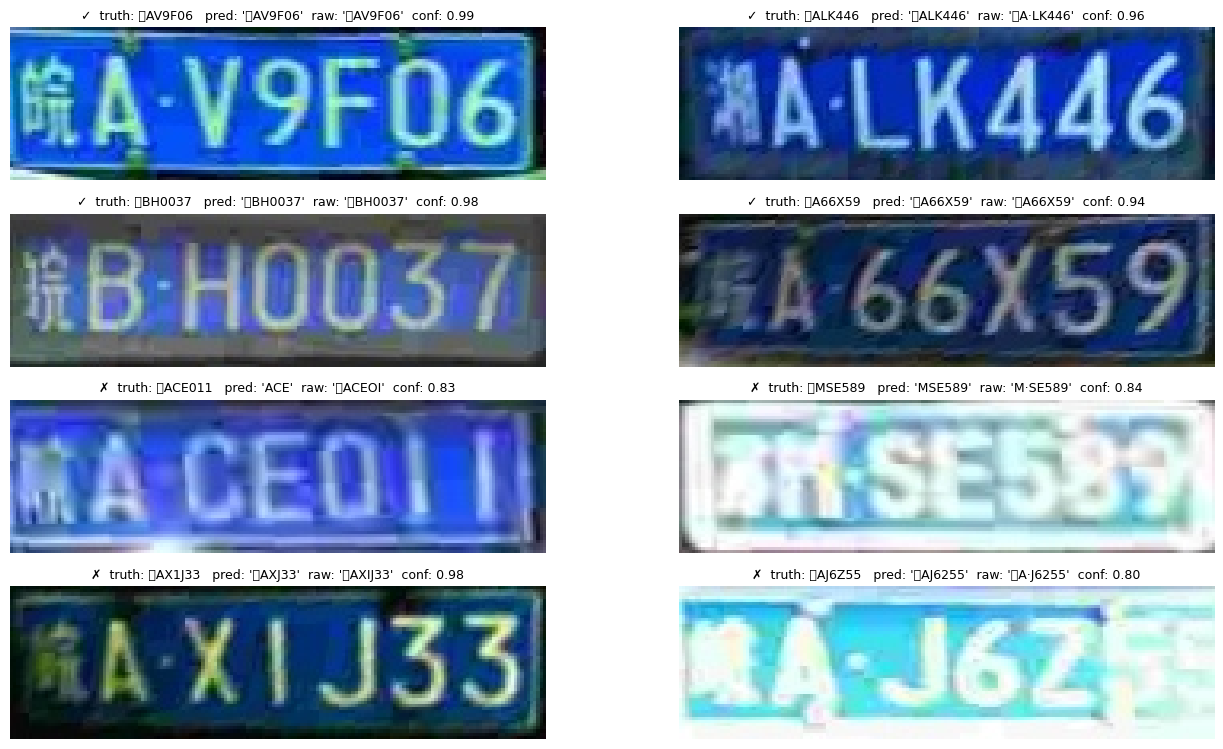

In [9]:
correct_sample   = results[results["full_match"]].sample(min(4, results["full_match"].sum()), random_state=0)
incorrect_sample = results[~results["full_match"]].sample(min(4, (~results["full_match"]).sum()), random_state=0)
sample = pd.concat([correct_sample, incorrect_sample]).reset_index(drop=True)

cols=2; rows=math.ceil(len(sample)/cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*7, rows*1.9))
axes = np.array(axes).reshape(-1)
for ax, (_, r) in zip(axes, sample.iterrows()):
    img = cv2.imread(r["path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ok = "✓" if r["full_match"] else "✗"
    title = (f'{ok}  truth: {r["truth"]}   pred: {r["clean_pred"]!r}'
             f'  raw: {r["raw_pred"]!r}  conf: {r["score"]:.2f}')
    ax.set_title(title, fontsize=9)
    ax.axis("off")
for ax in axes[len(sample):]: ax.axis("off")
plt.tight_layout(); plt.show()

In [10]:
results.to_csv(OUT_DIR / "paddleocr_predictions.csv", index=False)

summary = {
    "model_name":         MODEL_NAME,
    "paddleocr_version":  paddleocr.__version__,
    "test_n":             int(len(results)),
    "full_plate_acc":     float(full_acc),
    "mean_edit_distance": float(mean_edit),
    "per_position_acc":   per_pos_acc.tolist(),
    "per_subset":         per_subset.reset_index().to_dict(orient="records"),
}
with open(OUT_DIR / "paddleocr_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved:")
print(f"  {OUT_DIR/'paddleocr_predictions.csv'}")
print(f"  {OUT_DIR/'paddleocr_summary.json'}")

Saved:
  paddleocr_baseline/paddleocr_predictions.csv
  paddleocr_baseline/paddleocr_summary.json
